# Can I set `temperature` on this model? — it depends on reasoning effort

**The question.** For OpenAI's newer *reasoning* models you cannot always choose
a `temperature`. Whether the API accepts it depends on the model's
**reasoning effort** setting. This notebook shows that relationship directly, one
model at a time.

**How to read every chart below.** Each is a small grid:

- **rows = reasoning effort** — `off` (reasoning turned off, `effort="none"` or
  omitted) vs `medium` (reasoning on).
- **columns = the `temperature` you request** — `0`, `0.2`, `1` (the default),
  `2`, and a "—" column meaning *temperature not sent at all*.
- **each cell** = what the API did when asked for that combination:
  - **accepted** — the call went through.
  - **refused** — the API returned an error rejecting that `temperature`.
  - **no `off` mode** — the model doesn't allow reasoning to be turned off, so
    that whole row can't be requested.

The pattern to look for: for many reasoning models the **`off` row is all
"accepted"** (any temperature is fine) while the **`medium` row accepts only
`temperature = 1`** — turning reasoning on locks temperature to its default.

Every result is a live one-call probe (snapshot-pinned model ids, tiny prompt).
Re-run to re-verify after any model refresh — these rules change release to release.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv("/data/home/xiong/dev/Fund_ISR/.env")
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not set" 

## The probe

One tiny function sends a single request for a given (model, effort, temperature)
and reports one of three plain outcomes. Nothing else in the notebook is more
complicated than calling this and drawing the result.

In [2]:
PROMPT = "Reply with the single word ok."
MAX_TOKENS = 512  # headroom so reasoning models still emit a visible token at effort=medium

def ask(model, effort, temperature, endpoint="chat"):
    """Send one request and report the outcome:
       'accepted'       - the call went through
       'refused'        - the temperature value was rejected
       'no-off-mode'    - the model won't accept effort='none' (reasoning always on)
       'no-effort-knob' - the model has no reasoning_effort argument at all
                          (classic non-reasoning models)
       'no-endpoint'    - the model isn't served on this endpoint at all
                          (e.g. codex / pro models are Responses-only)
    """
    try:
        if endpoint == "chat":
            kw = dict(model=model, messages=[{"role": "user", "content": PROMPT}],
                      max_completion_tokens=MAX_TOKENS)
            if effort is not None:      kw["reasoning_effort"] = effort
            if temperature is not None: kw["temperature"] = temperature
            client.chat.completions.create(**kw)
        else:  # responses endpoint
            kw = dict(model=model, input=PROMPT, max_output_tokens=MAX_TOKENS)
            if effort is not None:      kw["reasoning"] = {"effort": effort}
            if temperature is not None: kw["temperature"] = temperature
            client.responses.create(**kw)
        return "accepted"
    except Exception as e:
        msg = str(e).lower()
        # model doesn't serve this endpoint at all (404)
        if "not supported in" in msg or ("not a chat model" in msg):
            return "no-endpoint"
        # classic models reject the reasoning argument itself
        if "unrecognized" in msg and ("reasoning" in msg or "effort" in msg):
            return "no-effort-knob"
        # reasoning models that don't allow turning reasoning off
        if ("effort" in msg or "'none'" in msg) and ("not support" in msg or "unsupported" in msg):
            return "no-off-mode"
        if "temperature" in msg and ("not support" in msg or "only the default" in msg):
            return "refused"
        return "refused"  # any other rejection of this combination

## Building one model's grid

For a model we sweep two effort settings (`off`, `medium`) × five temperature
requests and collect the outcomes into a small table, then draw it as a colored
grid. The colors are backed by the text in each cell, so the chart is readable
without relying on color alone.

In [3]:
EFFORTS = [("off", "none"), ("medium", "medium")]   # (label shown, value sent)
TEMPS   = [("—", None), ("0", 0), ("0.2", 0.2), ("1", 1), ("2", 2)]

# outcome -> integer code + display color. Text in every cell means color is
# never the sole signal (colorblind-safe by construction).
STATUS = {"accepted": 0, "refused": 1, "no-off-mode": 2, "no-effort-knob": 2, "no-endpoint": 2}
STATUS_COLORS = ["#2166AC", "#D6604D", "#BFBFBF"]   # blue=accepted / red=refused / grey=n/a
STATUS_LABEL  = {"accepted": "accepted", "refused": "refused", "no-off-mode": "no off mode",
                 "no-effort-knob": "n/a", "no-endpoint": "n/a"}

def probe_grid(model, endpoint="chat"):
    """Reasoning models: full effort x temperature grid (rows=effort, cols=temp)."""
    rows = {}
    for eff_label, eff_val in EFFORTS:
        rows[eff_label] = [ask(model, eff_val, t_val, endpoint) for _, t_val in TEMPS]
    return pd.DataFrame(rows, index=[t for t, _ in TEMPS]).T

def probe_temp_row(model, endpoint="chat"):
    """Non-reasoning models: temperature only, no effort argument (single row)."""
    row = [ask(model, None, t_val, endpoint) for _, t_val in TEMPS]
    return pd.DataFrame({("no effort knob"): row}, index=[t for t, _ in TEMPS]).T

def panel(ax, grid, title, show_ylabels=True, show_xlabels=True):
    """Draw one grid onto a given Axes. Shared by show_grid and the overview."""
    codes = grid.apply(lambda col: col.map(STATUS)).astype(int).values  # map avoids replace() downcast warning
    ax.imshow(codes, cmap=ListedColormap(STATUS_COLORS), vmin=0, vmax=2, aspect="auto")
    ax.set_xticks(range(grid.shape[1]), grid.columns if show_xlabels else [""] * grid.shape[1])
    ax.set_yticks(range(grid.shape[0]), grid.index if show_ylabels else [""] * grid.shape[0])
    ax.set_title(title, fontsize=9.5, pad=5)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, STATUS_LABEL[grid.iat[i, j]], ha="center", va="center",
                    color="white", fontsize=7)
    ax.set_xticks(np.arange(-.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)

def show_grid(grid, model, endpoint="chat", note=""):
    fig, ax = plt.subplots(figsize=(6.2, 1.3 + 0.45 * grid.shape[0]))
    panel(ax, grid, f"{model}  ·  {endpoint}")
    ax.set_xlabel("temperature requested"); ax.set_ylabel("reasoning effort")
    if note:
        fig.text(0.5, -0.10, note, ha="center", fontsize=8.5, style="italic", color="#444")
    plt.tight_layout(); plt.show()

def overview(specs, ncols=2, title="Temperature × reasoning-effort — all scenarios at a glance"):
    """specs: list of (label, grid). Lay them out as small multiples."""
    n = len(specs); nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.4 * ncols, 1.9 * nrows))
    axes = np.array(axes).reshape(-1)
    for k, (label, grid) in enumerate(specs):
        panel(axes[k], grid, label)
    for k in range(len(specs), len(axes)):
        axes[k].axis("off")
    fig.suptitle(title, fontsize=12, y=1.0)
    # shared legend
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=STATUS_COLORS[0], label="accepted"),
               Patch(facecolor=STATUS_COLORS[1], label="refused"),
               Patch(facecolor=STATUS_COLORS[2], label="n/a (no off-mode / no knob / wrong endpoint)")]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
               fontsize=8.5, bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])
    plt.show()

## Overview — every scenario in one figure

The small multiples below put all the representative behaviours side by side, so
the whole story reads at a glance before the per-model detail sections. Same grid
convention everywhere: **rows = reasoning effort**, **columns = temperature
requested**, blue = accepted, red = refused, grey = not applicable. Each panel is
one live probe, so this cell makes the API calls; the detail sections that follow
re-probe individually with explanatory notes.

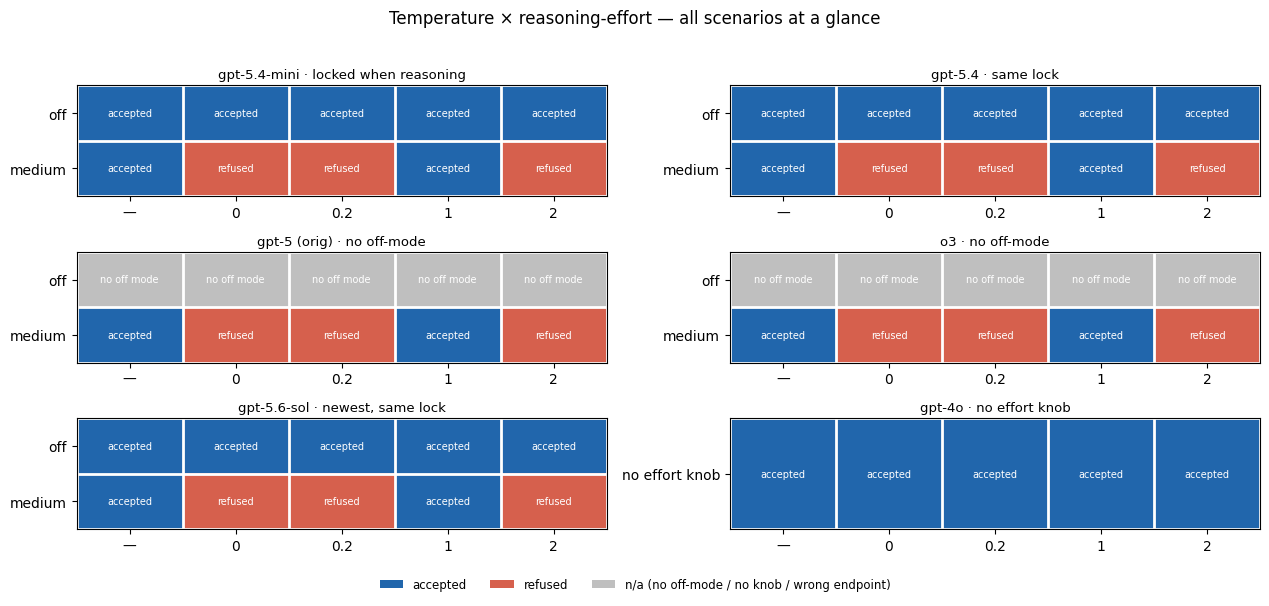

In [4]:
# One combined figure covering all representative scenarios.
# codex/pro models are Responses-only, so probe those on the responses endpoint.
overview_specs = [
    ("gpt-5.4-mini · locked when reasoning", probe_grid("gpt-5.4-mini-2026-03-17", "chat")),
    ("gpt-5.4 · same lock",                  probe_grid("gpt-5.4-2026-03-05", "chat")),
    ("gpt-5 (orig) · no off-mode",           probe_grid("gpt-5-2025-08-07", "chat")),
    ("o3 · no off-mode",                     probe_grid("o3-2025-04-16", "chat")),
    ("gpt-5.6-sol · newest, same lock",      probe_grid("gpt-5.6-sol", "chat")),
    ("gpt-4o · no effort knob",              probe_temp_row("gpt-4o-2024-08-06", "chat")),
]
overview(overview_specs, ncols=2)

## 1 · `gpt-5.4-mini` — the model this project uses

This is the workhorse for the general-agreement scoring. It is the clearest
example of the lock: **any** temperature is fine with reasoning off, but with
reasoning on, only the default `1` survives.

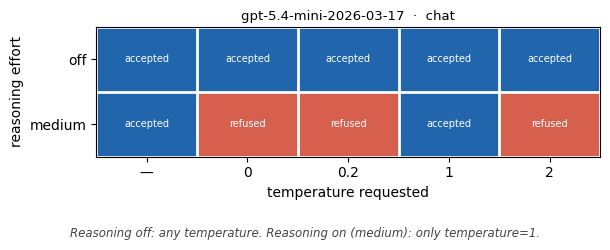

,—,0,0.2,1,2
off,accepted,accepted,accepted,accepted,accepted
medium,accepted,refused,refused,accepted,refused


In [5]:
g = probe_grid("gpt-5.4-mini-2026-03-17", "chat")
show_grid(g, "gpt-5.4-mini-2026-03-17", "chat",
          note="Reasoning off: any temperature. Reasoning on (medium): only temperature=1.")
g

## 2 · `gpt-5.4` — same lock, full-size model

The flagship 5.4 behaves identically, confirming this is a family rule, not a
mini-model quirk.

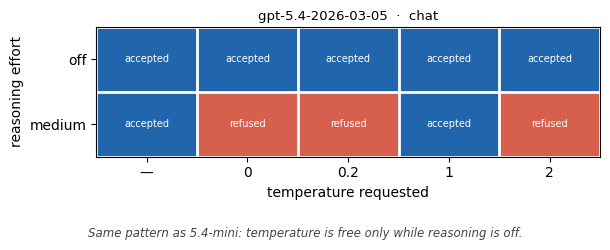

,—,0,0.2,1,2
off,accepted,accepted,accepted,accepted,accepted
medium,accepted,refused,refused,accepted,refused


In [6]:
g = probe_grid("gpt-5.4-2026-03-05", "chat")
show_grid(g, "gpt-5.4-2026-03-05", "chat",
          note="Same pattern as 5.4-mini: temperature is free only while reasoning is off.")
g

## 3 · `gpt-5` (original) — reasoning can't be turned off

The first GPT-5 has **no `off` mode** — `effort="none"` is rejected outright, so
there is no setting under which you can freely choose a temperature. The whole
`off` row is unavailable.

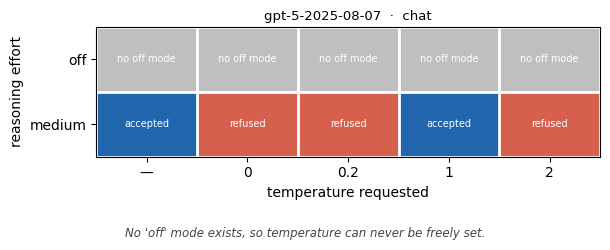

,—,0,0.2,1,2
off,no-off-mode,no-off-mode,no-off-mode,no-off-mode,no-off-mode
medium,accepted,refused,refused,accepted,refused


In [7]:
g = probe_grid("gpt-5-2025-08-07", "chat")
show_grid(g, "gpt-5-2025-08-07", "chat",
          note="No 'off' mode exists, so temperature can never be freely set.")
g

## 4 · `o3` — the o-series behaves like original GPT-5

The reasoning-first o-series (o1/o3/o4-mini) also has no `off` mode; temperature
is effectively never adjustable.

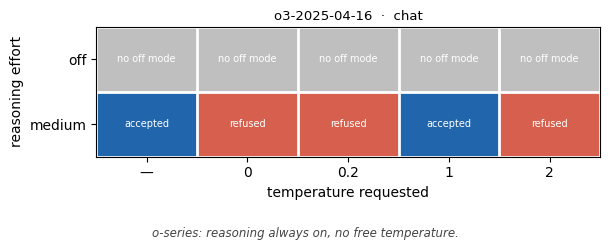

,—,0,0.2,1,2
off,no-off-mode,no-off-mode,no-off-mode,no-off-mode,no-off-mode
medium,accepted,refused,refused,accepted,refused


In [8]:
g = probe_grid("o3-2025-04-16", "chat")
show_grid(g, "o3-2025-04-16", "chat",
          note="o-series: reasoning always on, no free temperature.")
g

## 5 · `gpt-5.6-sol` — the newest models follow the same lock

The latest 5.6 family shows the same clean lock: any temperature with reasoning
off, only the default `1` once reasoning is on. (These newest snapshots are the
most likely to change between releases, so it is still worth re-probing the exact
one you plan to use rather than assuming.)

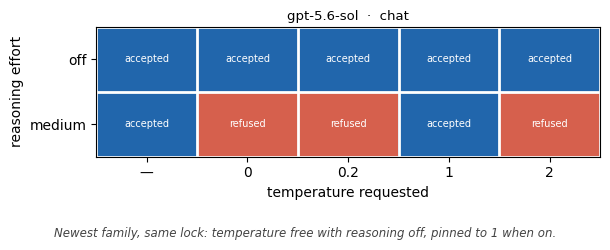

,—,0,0.2,1,2
off,accepted,accepted,accepted,accepted,accepted
medium,accepted,refused,refused,accepted,refused


In [9]:
g = probe_grid("gpt-5.6-sol", "chat")
show_grid(g, "gpt-5.6-sol", "chat",
          note="Newest family, same lock: temperature free with reasoning off, pinned to 1 when on.")
g

## 6 · `gpt-4o` and `gpt-4.1` — non-reasoning baseline

Classic (non-reasoning) models have **no reasoning-effort knob at all** — so
there is no effort row to sweep, just the temperature question. They accept every
temperature. This is the contrast case: what "temperature always works" looks
like.

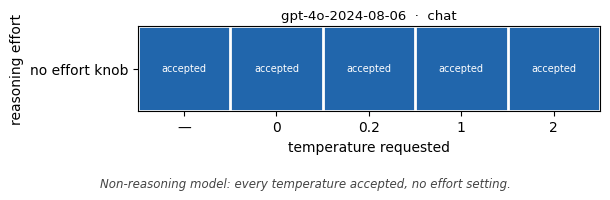

,—,0,0.2,1,2
no effort knob,accepted,accepted,accepted,accepted,accepted


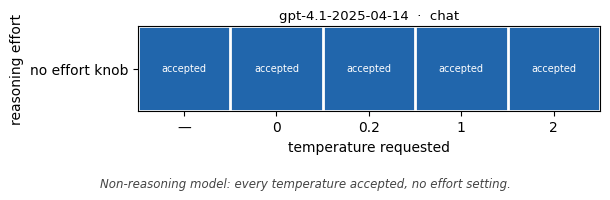

,—,0,0.2,1,2
no effort knob,accepted,accepted,accepted,accepted,accepted


In [10]:
for m in ["gpt-4o-2024-08-06", "gpt-4.1-2025-04-14"]:
    g = probe_temp_row(m, "chat")   # no effort argument — classic models have no such knob
    show_grid(g, m, "chat", note="Non-reasoning model: every temperature accepted, no effort setting.")
    display(g)

## 6.5 · Variants within one generation — the GPT-5.2 family

The rule can differ *within a single model generation*. GPT-5.2 ships several
variants; here is the same effort × temperature grid across four of them. Note
`codex` and `pro` are **Responses-only** (they 404 on Chat Completions), so those
two are probed on the `responses` endpoint — a grey "n/a" on the chat grid would
just mean "wrong door," not "temperature refused."

What to look for:

- **`gpt-5.2`** (base) — the clean lock: temperature free with reasoning off,
  pinned to `1` when on.
- **`gpt-5.2-chat-latest`** — has **no off-mode**, but still only accepts
  `temperature=1` while reasoning.
- **`gpt-5.2-codex`** / **`gpt-5.2-pro`** — served only on Responses; probed
  there.

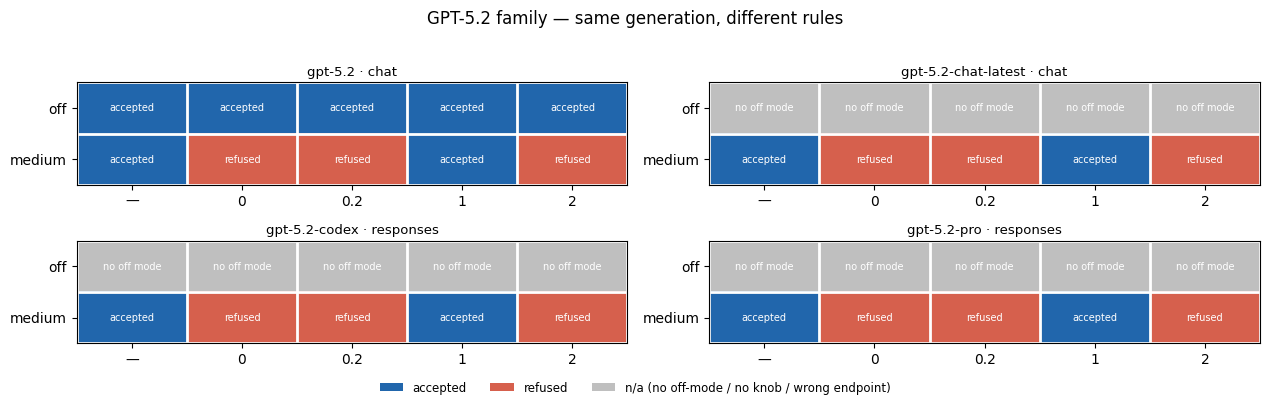


gpt-5.2 · chat
               —         0       0.2         1         2
off     accepted  accepted  accepted  accepted  accepted
medium  accepted   refused   refused  accepted   refused

gpt-5.2-chat-latest · chat
                  —            0          0.2            1            2
off     no-off-mode  no-off-mode  no-off-mode  no-off-mode  no-off-mode
medium     accepted      refused      refused     accepted      refused

gpt-5.2-codex · responses
                  —            0          0.2            1            2
off     no-off-mode  no-off-mode  no-off-mode  no-off-mode  no-off-mode
medium     accepted      refused      refused     accepted      refused

gpt-5.2-pro · responses
                  —            0          0.2            1            2
off     no-off-mode  no-off-mode  no-off-mode  no-off-mode  no-off-mode
medium     accepted      refused      refused     accepted      refused


In [11]:
# GPT-5.2 family across four variants. base + chat-latest live on chat;
# codex + pro are Responses-only, so probe them there.
gpt52_specs = [
    ("gpt-5.2 · chat",              probe_grid("gpt-5.2-2025-12-11", "chat")),
    ("gpt-5.2-chat-latest · chat",  probe_grid("gpt-5.2-chat-latest", "chat")),
    ("gpt-5.2-codex · responses",   probe_grid("gpt-5.2-codex", "responses")),
    ("gpt-5.2-pro · responses",     probe_grid("gpt-5.2-pro", "responses")),
]
overview(gpt52_specs, ncols=2, title="GPT-5.2 family — same generation, different rules")

# also print the raw grids for the record
for label, g in gpt52_specs:
    print(f"\n{label}")
    print(g.to_string())

## 7 · Does the endpoint matter?

The two ways to call these models — Chat Completions and Responses — can differ.
Here is the project's model on both. Where they diverge, pin the endpoint you
actually use.

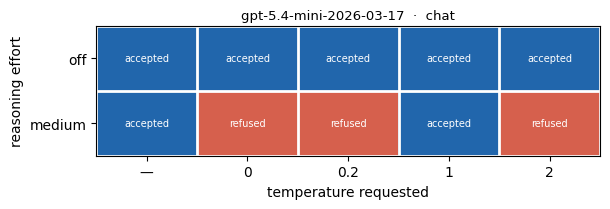

,—,0,0.2,1,2
off,accepted,accepted,accepted,accepted,accepted
medium,accepted,refused,refused,accepted,refused


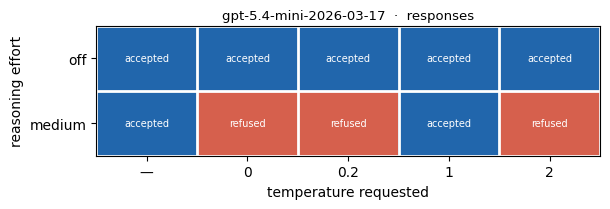

,—,0,0.2,1,2
off,accepted,accepted,accepted,accepted,accepted
medium,accepted,refused,refused,accepted,refused


In [12]:
for ep in ["chat", "responses"]:
    g = probe_grid("gpt-5.4-mini-2026-03-17", ep)
    show_grid(g, "gpt-5.4-mini-2026-03-17", ep)
    display(g)

## Summary — the three behaviours

| Behaviour | Representative models | What it means for you |
|---|---|---|
| **Temperature locks when reasoning is on** | `gpt-5.4`, `gpt-5.4-mini`, `gpt-5.2`, `gpt-5.1` | You *can* set temperature only with reasoning off (`effort="none"`). With reasoning on, only `temperature=1` is accepted. |
| **No "off" mode at all** | original `gpt-5`/`mini`/`nano`, `o1`, `o3`, `o4-mini` | Reasoning is always on, so temperature is effectively never adjustable. |
| **Temperature always free** | `gpt-4o`, `gpt-4.1`, `gpt-4`, `gpt-3.5` | Classic models: no reasoning knob, every temperature accepted. |

**Why this matters for the repeat-×10 randomness study.** The project scores with
`gpt-5.4-mini` at `temperature=1`. That value is accepted precisely because it is
the *only* one allowed once the model is reasoning — you cannot lower it to `0` to
make the output deterministic. So the run-to-run variation seen in that study is
not a tuning oversight; it is a structural property of scoring with a reasoning
model whose temperature is pinned to its default.